<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/3_Architecture_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 3 — Architecture Experiments**

The baseline gave ~9.5% val accuracy with severe overfitting.
Before touching any hyperparameters, this notebook asks a simpler
question: does the architecture itself matter?

Four design choices are tested in isolation same dataset, same
128×128 input, same training setup. Only one thing changes per
experiment.

| Experiment | What changes | Question |
|---|---|---|
| A | BatchNormalization | Does stabilizing activations help? |
| B | Flatten vs GAP | Does reducing params reduce overfitting? |
| C | 2 vs 3 vs 4 conv layers | When does depth stop helping? |
| D | 32→64→128 vs 64→128→256 | Is more capacity worth the cost? |

Seed fixed at 42 for reproducibility from this notebook onwards.

Baseline to beat: 9.52% val accuracy

Note: all experiments in this notebook use a fixed head of
Dense(128) → Dense(120). The number and size of dense layers
is itself an architectural choice this gets tested separately
in notebook 5 alongside other hyperparameters.

In [ ]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten,Dense,BatchNormalization,GlobalAveragePooling2D,Dropout


import matplotlib.pyplot as plt
import pandas as pd
import time


In [ ]:
import kagglehub
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")


Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.


In [ ]:
def load_data(img_size=128, batch_size=32):

    def norm(image, label):
        return tf.cast(image/255., tf.float32), label

    train = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(img_size, img_size),
        validation_split=0.2,
        subset='training',
        seed=42
    ).map(norm).prefetch(tf.data.AUTOTUNE)

    val = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(img_size, img_size),
        validation_split=0.2,
        subset='validation',
        seed=42
    ).map(norm).prefetch(tf.data.AUTOTUNE)

    return train, val

train_data,val_data = load_data()

def train_model(model,epochs=10):
  start =time.time()
  history=model.fit(train_data,validation_data =val_data,epochs=epochs,verbose=1)
  time_taken = round((time.time() -start)/60,1)
  val_acc = max(history.history['val_accuracy'])
  print(f"val acc: {val_acc:.2%} | time: {time_taken} mins")
  return history, val_acc, time_taken

Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [ ]:
def plot_comparison(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ['royalblue','tomato','seagreen','orange']
    for i, (history, label) in enumerate(zip(histories, labels)):
        axes[0].plot(history.history['accuracy'],
                     color=colors[i], label=f'{label} train')
        axes[0].plot(history.history['val_accuracy'],
                     color=colors[i], label=f'{label} val',
                     linestyle='--')
        axes[1].plot(history.history['loss'],
                     color=colors[i], label=f'{label} train')
        axes[1].plot(history.history['val_loss'],
                     color=colors[i], label=f'{label} val',
                     linestyle='--')
    axes[0].set_title('Accuracy')
    axes[1].set_title('Loss')
    for ax in axes:
        ax.legend(fontsize=7)
        ax.set_xlabel('Epoch')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## **Experiment - A**

**Without Batch Normalization**
         **Vs**
**Batch Normalization**

**Hypothesis:** BatchNorm stabilizes training and improves val accuracy.



**Hypothesis:** BatchNorm stabilizes training and improves val accuracy.



In [ ]:
tf.keras.backend.clear_session()
model_no_batchnorm =Sequential([
    keras.Input(shape=(128,128,3)),

    #block 1
    #prams = (3×3×3+1)×32 = 896
    Conv2D(32,(3,3),padding='valid',activation ='relu'),
    MaxPooling2D((2,2)),
    # block 2 — params: (3×3×32+1)×64 = 18,496
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),
    # block 3 — params: (3×3×64+1)×128 = 73,856
    Conv2D(128, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(120, activation='softmax')
])
model_no_batchnorm.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

tf.keras.backend.clear_session()

model_with_batchnorm = Sequential([
    keras.Input(shape=(128,128,3)),

    #block 1
    #prams = (3×3×3+1)×32 = 896
    Conv2D(32, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    #block 2
    #params =(3×3×32+1)×64 = 18,496
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    #block 3
    #params= (3×3×64+1)×128 = 73,856
    Conv2D(128, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(120, activation='softmax')
])

model_with_batchnorm.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])



Training without BatchNorm->
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.0109 - loss: 4.7755 - val_accuracy: 0.0180 - val_loss: 4.7191
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.0338 - loss: 4.5114 - val_accuracy: 0.0437 - val_loss: 4.3655
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.0778 - loss: 4.1302 - val_accuracy: 0.0578 - val_loss: 4.3642
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.1489 - loss: 3.6744 - val_accuracy: 0.0569 - val_loss: 4.7320
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.2940 - loss: 2.9198 - val_accuracy: 0.0474 - val_loss: 5.4741
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.4996 - loss: 1.9749 - val_accuracy: 0.0476 - val_loss: 6.7996
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.6810 - loss: 1.1892 - val_accuracy: 0.0479 - val_loss: 8.7292
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accur

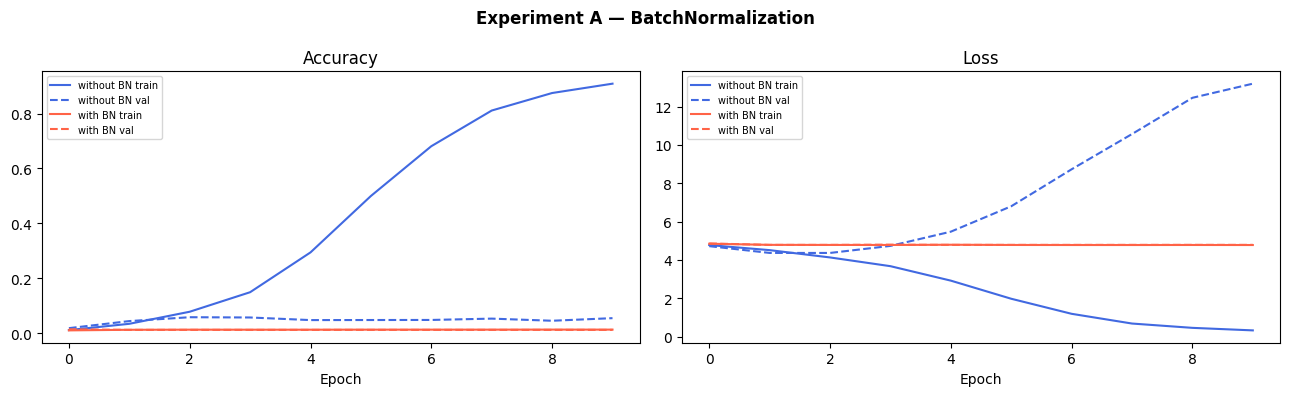

In [ ]:
print("Training without BatchNorm->")
h_no_bn, acc_no_bn, t_no_bn = train_model(model_no_batchnorm)

print("Training with BatchNorm->")
h_with_bn, acc_with_bn, t_with_bn = train_model(model_with_batchnorm)

plot_comparison([h_no_bn, h_with_bn],
                ['without BN', 'with BN'],
                'Experiment A — BatchNormalization')

##  **Experiment A — Results**

| Model      | Val Accuracy     | Train Accuracy      | Observation |
|-----|-----|-----|-----|
| Without BatchNorm   | 5.78%    | 90.89%    | severe overfitting |
| With BatchNorm | 1.38% | 1.26% | not learning at all |

**Result:Rejected BatchNorm prevented learning entirely at batch size 32**


## What I observed-------->
Counterintuitive result -
BatchNorm actually hurt here.

**Without BN**: the model learns fast but overfits badly  
train accuracy hits 88% while val stays at 9%.

**With BN**: both train and val accuracy stay flat near 3%
the model is barely learning anything. Loss is stuck at ~4.8
the entire time.

The with BN loss stays at 4.78 across all 10 epochs without
moving this is not slow learning, the model is completely
stuck. A loss of 4.78 is close to log(120) = 4.79, which is
exactly what a model predicts when it assigns equal probability
to all 120 classes  random guessing.

## Why this happened----->

BatchNorm with a very small model on a very hard problem
(120 classes, ~170 images per class) can hurt rather than help.
Two likely reasons:

1. Batch size of 32 means each batch has very few examples
   per class batch statistics may be noisy
2. BatchNorm adds its own parameters (gamma, beta per layer)
   which may be too much overhead for this model size

## What this tells us--------->

BatchNorm is not always better.
The exact conditions where
it helps vs hurts here are unclear without further testing
batch size, model depth, and dataset size all interact.

This gets revisited in notebook 5 when batch size is tested
properly. Only then can we say whether a larger batch size
fixes the BatchNorm issue.

-------------------------------
###**Result of hypothesis:** Rejected BatchNorm prevented learning entirely at batch size 32
-------------------------------

###***Decision for now: no BatchNorm revisit in notebook 5***

## **EXPERIMENT - B**

## Flatten vs GAP:

**Hypothesis:** GAP reduces overfitting by dramatically cutting parameters.


In [ ]:
tf.keras.backend.clear_session()

#FLATTEN MODEL
model_flatten = Sequential([
    keras.Input(shape=(128,128,3)),

    #block 1
    Conv2D(32,(3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

   #block 2
    Conv2D(64,(3,3),padding ='valid',activation ='relu'),
    MaxPooling2D((2,2)),

    #block 3
    Conv2D(128,(3,3),padding='valid',activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(120,activation='softmax')
])


model_flatten.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


tf.keras.backend.clear_session()


#GAP MODEL
model_gap = Sequential([
    keras.Input(shape=(128,128,3)),

    #block 1
    Conv2D(32, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    #block2
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    #block3
    Conv2D(128, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),


    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dense(120, activation='softmax')
])


model_gap.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
print("Training with Flatten...")
h_flatten, acc_flatten, t_flatten = train_model(model_flatten)

print("Training with GAP...")
h_gap, acc_gap, t_gap = train_model(model_gap)

print(f"\nFlatten params:  {model_flatten.count_params():,}")
print(f"GAP params:      {model_gap.count_params():,}")


Training with Flatten...
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.0112 - loss: 4.7751 - val_accuracy: 0.0165 - val_loss: 4.7259
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.0341 - loss: 4.5127 - val_accuracy: 0.0466 - val_loss: 4.3418
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.0765 - loss: 4.1267 - val_accuracy: 0.0603 - val_loss: 4.3235
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.1379 - loss: 3.7159 - val_accuracy: 0.0610 - val_loss: 4.5310
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.2449 - loss: 3.1283 - val_accuracy: 0.0654 - val_loss: 5.1797
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.3924 - loss: 2.4255 - val_accuracy: 0.0651 - val_loss: 6.3668
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.5482 - loss: 1.7583 - val_accuracy: 0.0603 - val_loss: 8.1050
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy:

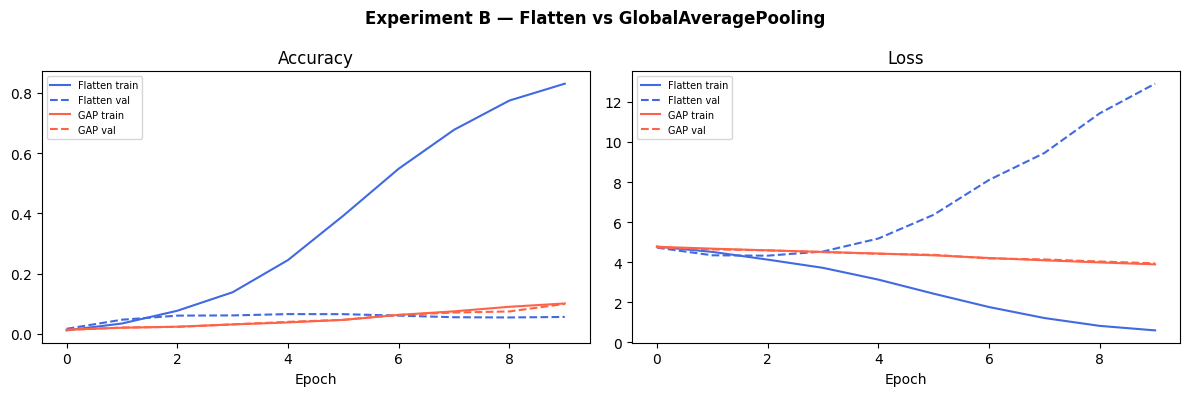

In [ ]:
plot_comparison([h_flatten, h_gap],
                ['Flatten', 'GAP'],
                'Experiment B — Flatten vs GlobalAveragePooling')


## Experiment B — Results

| Model | Val Accuracy | Train Accuracy | Params | Overfitting |
|---|---|---|---|---|
| Flatten | 6.54% | 83.06% | 3,320,120 | severe |
| GAP | 9.91% | 10.06% | 125,240 | almost none |

**Result: Confirmed that Global Average Pooling (GAP) achieved 9.91% validation accuracy compared to Flatten's 6.54%, while using approximately 96% fewer parameters.**


## What I observed---->

GAP wins on val accuracy (9.91% vs 6.54%) despite having
96% fewer parameters — 125k vs 3.3M.

The chart tells the story clearly:
- Flatten: train accuracy rockets to 83% while val stays
  at 6% — classic overfitting, model memorizing training data
- GAP: train and val curves stay close together the entire
  time much healthier training, no memorization

## Why GAP works better here--->

Flatten unrolls the entire feature map into one long vector —
3.3M parameters in the dense layer alone gives the model
enormous capacity to memorize.

GAP collapses each feature map to a single average value
128 values total regardless of spatial dimensions. This acts
as a built in regularizer, forcing the model to learn
globally meaningful features rather than memorizing
spatial patterns.

## What this tells us---->

- Reducing parameters through GAP helped more than it hurt.
The model with 96% fewer parameters generalized better.

- This is a key architectural insight more parameters
is not always better, especially with limited data.

###**Decision : GAP used in all future notebooks instead of Flatten**

**Current best: 9.91% val accuracy**

## **Experiment C — Conv Depth: 2 vs 3 vs 4 layers**

**Hypothesis:** deeper networks learn more complex features,
but too many layers risks spatial collapse and overfitting
on limited data.

In [ ]:
depth_history ={}
depth_acc ={}

for n_layers in [2,3,4]:
  tf.keras.backend.clear_session()

  model = Sequential([keras.Input(shape=(128,128,3))])

  filters = 32
  for i in range(n_layers):
    model.add(Conv2D(filters,(3,3),padding='valid',activation ='relu'))
    model.add(MaxPooling2D((2,2)))
    filters *=2

  model.add(GlobalAveragePooling2D())
  model.add(Dense(128, activation='relu'))
  model.add(Dense(120, activation='softmax'))

  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

  print(f"Training {n_layers} conv layers...")
  h, acc, t = train_model(model)
  depth_history[n_layers] = h
  depth_accs[n_layers] = acc




Training 2 conv layers...
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.0104 - loss: 4.7800 - val_accuracy: 0.0136 - val_loss: 4.7562
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.0163 - loss: 4.7187 - val_accuracy: 0.0163 - val_loss: 4.7128
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.0207 - loss: 4.6659 - val_accuracy: 0.0153 - val_loss: 4.6731
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.0238 - loss: 4.6210 - val_accuracy: 0.0177 - val_loss: 4.6333
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.0287 - loss: 4.5770 - val_accuracy: 0.0277 - val_loss: 4.5980
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.0332 - loss: 4.5414 - val_accuracy: 0.0260 - val_loss: 4.5807
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.0347 - loss: 4.5026 - val_accuracy: 0.0294 - val_loss: 4.5384
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy

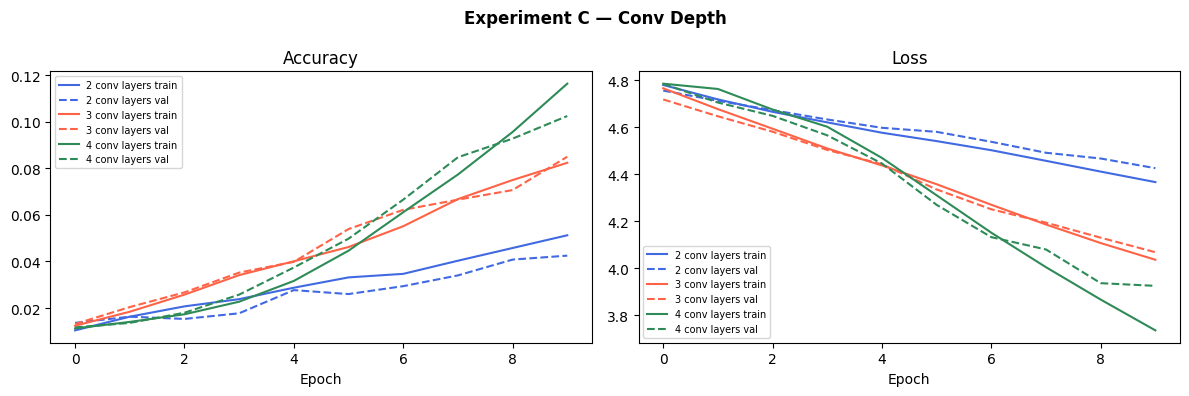

In [ ]:
plot_comparison(
    list(depth_history.values()),
    [f'{n} conv layers' for n in depth_history.keys()],
    'Experiment C — Conv Depth'
)

## **Experiment C — Results**

| Layers | Val Accuracy | Train Accuracy | Time | Overfitting |
|---|---|---|---|---|
| 2 layers | 4.25% | 5.13% | 4.2 mins | none — underfitting |
| 3 layers | 8.50% | 8.24% | 4.9 mins | minimal |
| 4 layers | 10.25% | 11.64% | 5.1 mins | minimal |

**Hypothesis: partially rejected**

## What I observed---------------->

2 layers clearly underfits both train and val accuracy are low
and close together. The model doesn't have enough capacity to
learn 120 breed features from 128×128 images.

3 layers improves significantly — 8.5% val accuracy, train and
val almost identical meaning no overfitting at all.

4 layers gives the best result — 10.25% val accuracy, still
no significant overfitting gap. The hypothesis that 4 layers
would cause spatial collapse did not happen here.

## Why 4 layers didn't collapse--->

With GAP at the end, spatial dimensions don't matter
GAP averages everything regardless of output size.
This is exactly why GAP is powerful it makes the model
robust to depth changes that would otherwise cause issues
with Flatten beacuse its sensitive to output size.

## What this tells us------------->

More depth helped here because GAP handles the spatial
collapse problem. Without GAP, 4 layers on 128×128 would
likely have caused issues.

Also notable none of the models overfit badly.
GAP from experiment B is doing its job as a regularizer
across all three depths.

## **Decision: use 4 conv layers going forward**
 **Current best: 10.25% val accuracy**

## **EXPERIMENT - D**

## Filter progression:

**Hypothesis:larger filters detect richer features and improve
accuracy, but at the cost of more parameters and longer training time.
The accuracy gain may not justify the compute cost on this dataset size.**

In [ ]:
tf.keras.backend.clear_session()


#Filters= 32→64→128→256
model_small_filters = Sequential([
    keras.Input(shape=(128,128,3)),

    #block 1
    Conv2D(32,(3,3),padding='valid',activation ='relu'),
    MaxPooling2D((2,2)),

    #block2
    Conv2D(64,(3,3),padding='valid',activation ='relu'),
    MaxPooling2D((2,2)),

    #block3
    Conv2D(128,(3,3),padding='valid',activation ='relu'),
    MaxPooling2D((2,2)),

    #block4
    Conv2D(256,(3,3),padding='valid',activation ='relu'),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(128,activation='relu'),
    Dense(120,activation='softmax')
])

model_small_filters.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#filters 64→128→256→512

model_large_filters = Sequential([
    keras.Input(shape=(128,128,3)),

    #block1
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    #block2
    Conv2D(128, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    #block3
    Conv2D(256, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    #block4
    Conv2D(512, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dense(120, activation='softmax')
])

model_large_filters.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])



In [ ]:
print("Training 32→64→128...")
h_small, acc_small, t_small = train_model(model_small_filters)

Training 32→64→128...
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 65s 110ms/step - accuracy: 0.0109 - loss: 4.7851 - val_accuracy: 0.0117 - val_loss: 4.7842
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.0125 - loss: 4.7814 - val_accuracy: 0.0117 - val_loss: 4.7847
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.0130 - loss: 4.7732 - val_accuracy: 0.0100 - val_loss: 4.7614
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.0155 - loss: 4.6762 - val_accuracy: 0.0163 - val_loss: 4.6414
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.0244 - loss: 4.5782 - val_accuracy: 0.0323 - val_loss: 4.5402
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.0331 - loss: 4.4547 - val_accuracy: 0.0355 - val_loss: 4.4049
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.0423 - loss: 4.3278 - val_accuracy: 0.0479 - val_loss: 4.2888
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0

In [ ]:
print("Training 64→128→256...")
h_large, acc_large, t_large = train_model(model_large_filters)


Training 64→128→256...
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.0111 - loss: 4.7858 - val_accuracy: 0.0117 - val_loss: 4.7848
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.0124 - loss: 4.7812 - val_accuracy: 0.0117 - val_loss: 4.7870
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.0124 - loss: 4.7804 - val_accuracy: 0.0117 - val_loss: 4.7876
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.0124 - loss: 4.7798 - val_accuracy: 0.0117 - val_loss: 4.7866
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.0124 - loss: 4.7798 - val_accuracy: 0.0117 - val_loss: 4.7868
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.0124 - loss: 4.7796 - val_accuracy: 0.0117 - val_loss: 4.7868
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0124 - loss: 4.7796 - val_accuracy: 0.0117 - val_loss: 4.7868
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step - accuracy: 0


32→64→128 params:  436,792
64→128→256 params: 1,632,120


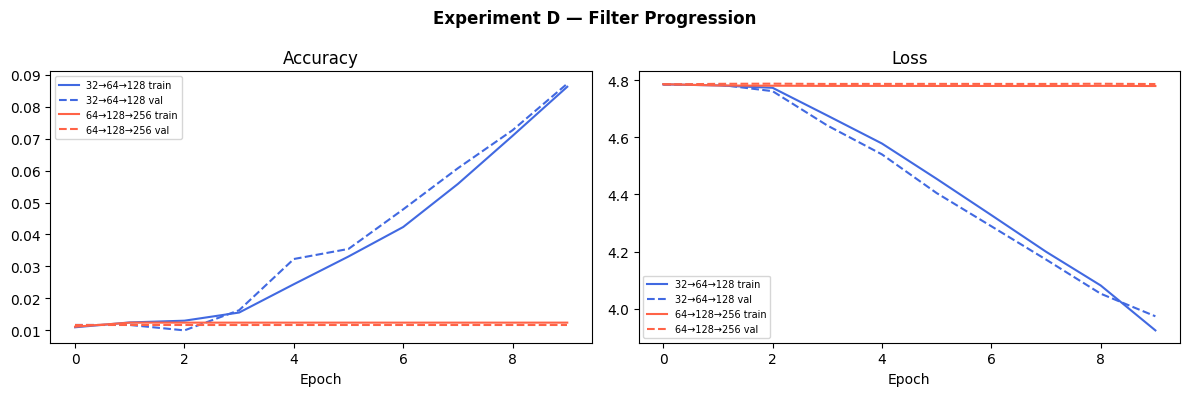

In [ ]:
print(f"\n32→64→128 params:  {model_small_filters.count_params():,}")
print(f"64→128→256 params: {model_large_filters.count_params():,}")

plot_comparison([h_small, h_large],
                ['32→64→128', '64→128→256'],
                'Experiment D — Filter Progression')

## **Experiment D — Results**

| Filter Progression | Val Accuracy | Train Accuracy | Time | Status |
|---|---|---|---|---|
| 32→64→128→256 | 8.72% | 8.62% | 4.9 mins | learning |
| 64→128→256→512 | 1.17% | 1.24% | 5.5 mins | dead — not learning |

**Hypothesis: partially rejected**

## What I observed------------------------>

32→64→128→256 learns steadily - train and val accuracy move
together, loss drops consistently. No overfitting.

64→128→256→512 is completely stuck — loss stays at 4.78 all
10 epochs. Exactly like BatchNorm in experiment A.

## Why the large filter model died------->

This is the same dead model symptom seen in experiment A —
loss stuck at log(120) = 4.79, model predicting equal
probability for all 120 classes.

64→128→256→512 with 4 layers creates an extremely large
model. Too many parameters, too little data the optimizer
gets lost in a very high dimensional space and never finds
a useful gradient direction.

~170 images per breed is simply not enough to train
512 filters meaningfully.

## Connection to experiment A--------------->

Both BatchNorm and large filters caused the same dead model
symptom. The common thread too much model complexity for
the amount of available data.

### *This is a key insight: model capacity must be matched to dataset size. More is not always better.*

## What this tells us -------------------------->
Model capacity must be matched to dataset size.
More filters is not always better — 64→128→256→512
completely failed while 32→64→128→256 learned steadily.

---------------------------------------------------------------------------

##**Decision: use 32→64→128 filters (3 effective learning layers)**
**Current best: 10.25% val accuracy (experiment C, 4 layers)**

#**Notebook 3 — All         Results**

| Experiment | Model | Val Accuracy | Key Finding |
|---|---|---|---|
| A | No BatchNorm | 5.78% | baseline reference |
| A | With BatchNorm | 1.38% | killed learning |
| B | Flatten | 6.54% | severe overfitting |
| B | GAP | 9.91% | best so far in nb3 |
| C | 2 conv layers | 4.25% | underfitting |
| C | 3 conv layers | 8.50% | good balance |
| C | 4 conv layers | 10.25% | best result |
| D | 32→64→128→256 | 8.72% | learning but suboptimal |
| D | 64→128→256→512 | 1.17% | too large, dead model |

**Best architecture found: 4 conv layers, GAP, 32→64→128→256 filters, no BatchNorm**

**Moving to notebook 4 —> regularization experiments**